# Explainable AI: COMPAS Predictions

Importing libraries

In [1]:
import pandas as pd

# for imputing modes and medians
from sklearn.impute import SimpleImputer

# for random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import shap

C:\Users\Eduard\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# ! Assign target !

In [2]:
target = 'is_recid'

Importing data

In [3]:
# change file name for data if using different version
dfOriginal = pd.read_csv("cox-violent-parsed_filt.csv")

Remove duplicates, only one row per name

In [4]:
dfProcessed = dfOriginal.drop_duplicates(subset=['name'])
dfProcessed.count()

id                          6560
name                       10855
first                      10855
last                       10855
sex                        10855
dob                        10855
age                        10855
age_cat                    10855
race                       10855
juv_fel_count              10855
decile_score               10855
juv_misd_count             10855
juv_other_count            10855
priors_count               10855
days_b_screening_arrest     9781
c_jail_in                   9781
c_jail_out                  9781
c_days_from_compas         10185
c_charge_degree            10185
c_charge_desc              10178
is_recid                   10855
r_charge_degree             3425
r_days_from_arrest          2281
r_offense_date              3425
r_charge_desc               3368
r_jail_in                   2281
violent_recid                  0
is_violent_recid           10855
vr_charge_degree             809
vr_offense_date              809
vr_charge_

Remove unused columns

In [5]:
dfProcessed = dfProcessed[['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree', target]]
dfProcessed.count()

sex                10855
age                10855
race               10855
juv_fel_count      10855
juv_misd_count     10855
juv_other_count    10855
priors_count       10855
c_charge_degree    10185
is_recid           10855
dtype: int64

Remove -1 is_recid (must be binary)

In [6]:
# What we expect to be dropped
# Just using this to double check
dfCheck = dfProcessed.loc[dfProcessed[target] < 0]
dfCheck.count()

sex                648
age                648
race               648
juv_fel_count      648
juv_misd_count     648
juv_other_count    648
priors_count       648
c_charge_degree      1
is_recid           648
dtype: int64

In [7]:
# Dropping the invalid is_recid values
dfProcessed = dfProcessed.loc[dfProcessed[target] > -1]
dfProcessed.count()

sex                10207
age                10207
race               10207
juv_fel_count      10207
juv_misd_count     10207
juv_other_count    10207
priors_count       10207
c_charge_degree    10184
is_recid           10207
dtype: int64

Missing value strategy
1. Numerical values --> MEDIAN imputation
2. Categorical values --> MODE imputation

In [8]:
print("Any NaN values?\n", dfProcessed.isnull().values.any())
# ^^ To check if any NaNs
# put it bc I tried a heatmap and it looked empty so double checking

Any NaN values?
 True


Smote? Impute from other dataset? Impute from same dataset?

In [9]:
# We should discuss what the plan is for this part

Dummy Model
(idk if this is the right approach?)

In [10]:
# all target = 0

## Random Forest
!Note!

Random Forest requires all data to be in numbers, so the categorical data needs to be enumerated before we are able to use it. This is fine for our situation because the categorical data is not unique to each individual and can easily be turned into numbers.

In [11]:
X = dfProcessed.drop(target, axis=1)
y = dfProcessed[target]

testSize = 0.3 
randNum = 44 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=testSize, random_state=randNum)

numCols = ['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count']

numImputer = SimpleImputer(strategy = 'median')
X_train[numCols] = numImputer.fit_transform(X_train[numCols])
#X_test[numCols] = numImputer.transform(X_test[numCols])

catCols = ['sex', 'race', 'c_charge_degree']

catImputer = SimpleImputer(strategy='most_frequent')
X_train[catCols] = catImputer.fit_transform(X_train[catCols])
#X_test[catCols] = catImputer.transform(X_test[catCols])








One-Hot Encoding

In [12]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output = False)
# handle_unknown prevents crash if it does not know the category
# puts 0 if it doesn't know it to indicate False
# sparse as False is important so it stores as a normal array

encoder.fit(X_train[catCols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [13]:
X_train_cat = encoder.transform(X_train[catCols])
X_test_cat = encoder.transform(X_test[catCols])

catNames = encoder.get_feature_names_out(catCols)

X_train_enc = pd.concat([
    X_train[numCols].reset_index(drop = True),
    pd.DataFrame(X_train_cat, columns = catNames)
], axis = 1)

X_test_enc = pd.concat([
    X_test[numCols].reset_index(drop = True),
    pd.DataFrame(X_test_cat, columns = catNames)
], axis = 1)

In [14]:
rf = RandomForestClassifier(n_estimators=300, random_state=randNum, min_samples_leaf=5, max_depth=10, class_weight='balanced')
rf.fit(X_train_enc, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=300, random_state=44)

In [15]:
# What did the model predict?
predictions = rf.predict(X_test_enc)
predictions

array([0, 1, 0, ..., 1, 0, 0], dtype=int64)

In [16]:
# The probabilities it gave to each prediction
rf.predict_proba(X_test_enc)

array([[0.58389918, 0.41610082],
       [0.30555334, 0.69444666],
       [0.7245296 , 0.2754704 ],
       ...,
       [0.28861522, 0.71138478],
       [0.5003294 , 0.4996706 ],
       [0.76902093, 0.23097907]])

In [17]:
# Importance of each feature (using the correct encoded column names)
importances = rf.feature_importances_
cols = X_train_enc.columns  # must match what the model was trained on

for col, imp in zip(cols, importances):
    print(f'Importance of {col} = {round(imp * 100, 2)}%.')

Importance of age = 28.46%.
Importance of juv_fel_count = 2.73%.
Importance of juv_misd_count = 4.44%.
Importance of juv_other_count = 5.2%.
Importance of priors_count = 39.02%.
Importance of sex_Female = 2.12%.
Importance of sex_Male = 2.49%.
Importance of race_African-American = 4.48%.
Importance of race_Asian = 0.24%.
Importance of race_Caucasian = 1.53%.
Importance of race_Hispanic = 1.03%.
Importance of race_Native American = 0.03%.
Importance of race_Other = 0.75%.
Importance of c_charge_degree_(CO3) = 0.0%.
Importance of c_charge_degree_(CT) = 0.0%.
Importance of c_charge_degree_(F1) = 0.96%.
Importance of c_charge_degree_(F2) = 0.97%.
Importance of c_charge_degree_(F3) = 2.26%.
Importance of c_charge_degree_(F5) = 0.01%.
Importance of c_charge_degree_(F6) = 0.01%.
Importance of c_charge_degree_(F7) = 0.49%.
Importance of c_charge_degree_(M1) = 1.66%.
Importance of c_charge_degree_(M2) = 0.92%.
Importance of c_charge_degree_(MO3) = 0.21%.
Importance of c_charge_degree_(NI0) = 0.

In [18]:
# Classification report returns precision, recall, F1, etc.
from sklearn.metrics import classification_report
print(classification_report(y_test, rf.predict(X_test_enc)))

              precision    recall  f1-score   support

           0       0.79      0.66      0.72      2047
           1       0.49      0.65      0.56      1016

    accuracy                           0.66      3063
   macro avg       0.64      0.66      0.64      3063
weighted avg       0.69      0.66      0.67      3063



# TreeSHAP

In [19]:
explainer = shap.TreeExplainer(rf)

# shap_values shape: (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_test_enc)
shap_class1_vals = shap_values[:, :, 1]  # class 1 = recidivism

# Wrap into Explanation object for waterfall/bar plots
shap_class1 = shap.Explanation(
    values=shap_class1_vals,
    base_values=explainer.expected_value[1],
    data=X_test_enc.values,
    feature_names=list(X_test_enc.columns)
)

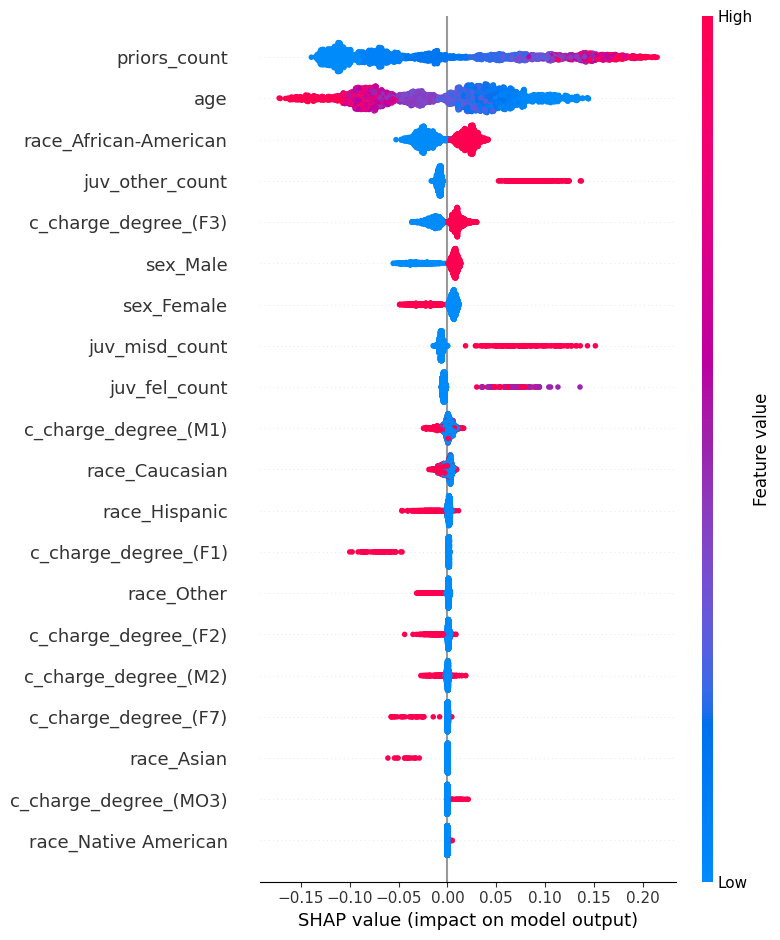

In [20]:
import matplotlib.pyplot as plt

# Beeswarm summary plot: Y axis = features ranked by importance 
#                       and X axis = SHAP value, if positive => pushes toward recidivism, if negative => away from recidivism
#                       Color  = feature value, red = high,blue = low
shap.summary_plot(shap_class1_vals, X_test_enc, max_display=20)

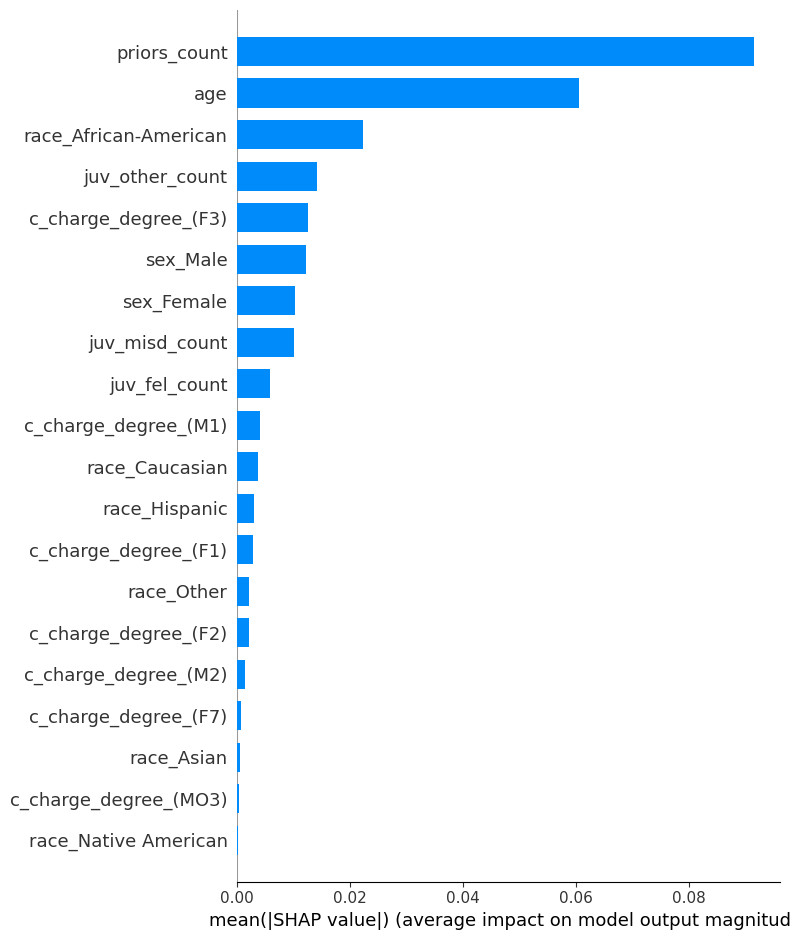

In [21]:
# most important features(mean SHAP value )
shap.summary_plot(shap_class1_vals, X_test_enc, plot_type='bar', max_display=20)

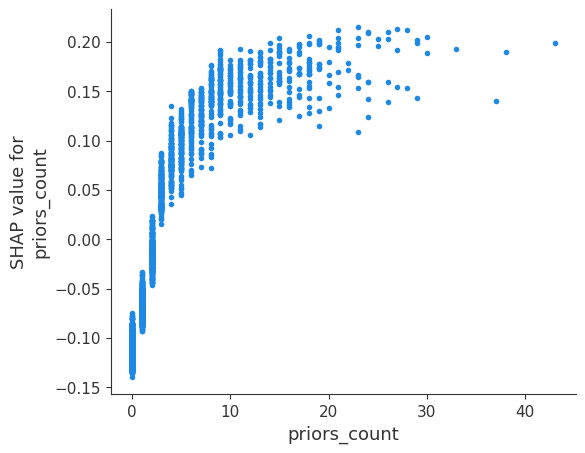

In [22]:
# SHAP dependence plot for priors_count
shap.dependence_plot(
    "priors_count",
    shap_class1_vals,
    X_test_enc,
    interaction_index=None
)


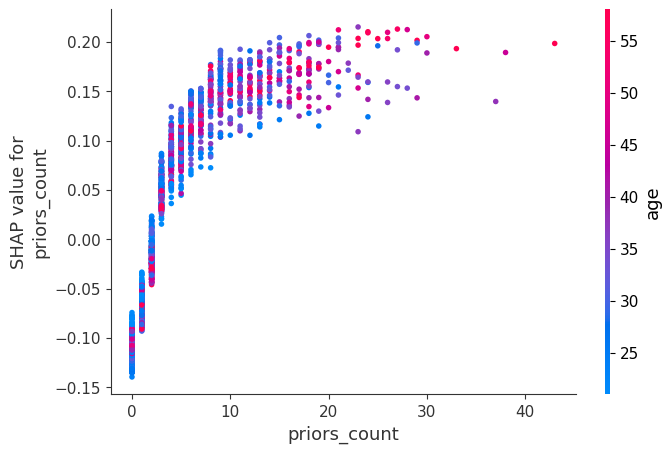

In [23]:
# SHAP interaction plot priors_count x age
shap.dependence_plot(
    "priors_count",
    shap_class1_vals,
    X_test_enc,
    interaction_index="age"
)


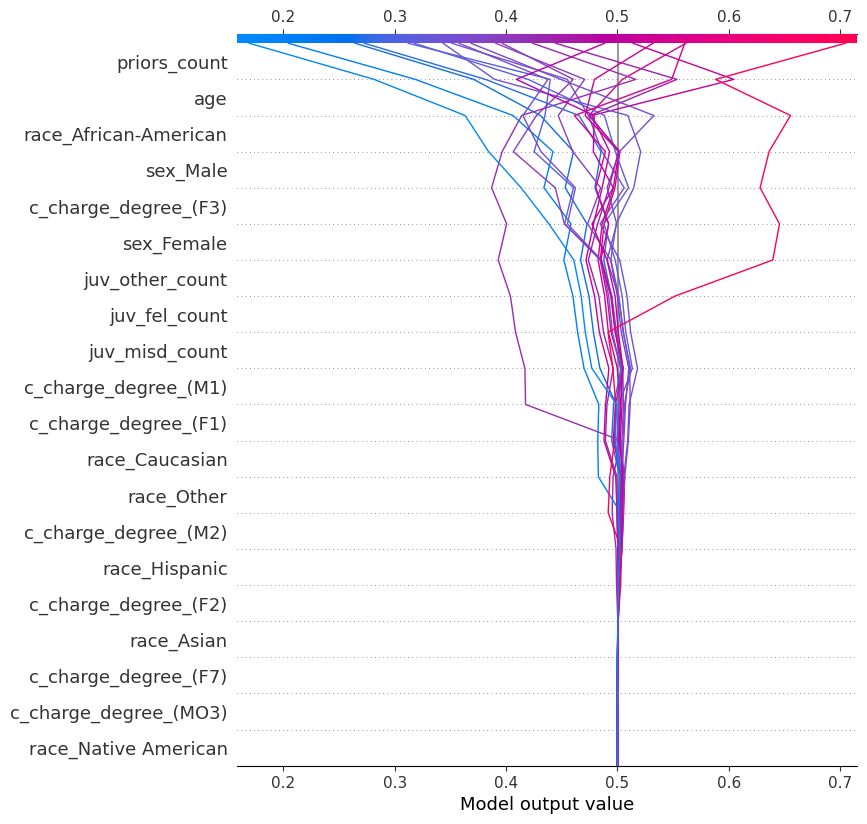

In [24]:
# SHAP decision plot for a small subset
sample_idx = X_test_enc.sample(20, random_state=randNum).index.to_numpy()
shap.decision_plot(
    explainer.expected_value[1],
    shap_class1_vals[sample_idx],
    X_test_enc.iloc[sample_idx],
    feature_names=list(X_test_enc.columns)
)


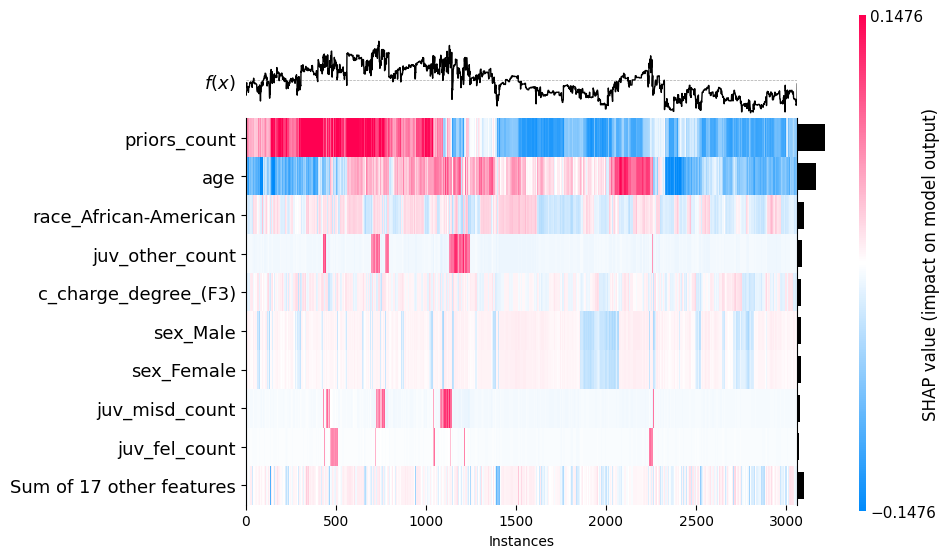

<Axes: xlabel='Instances'>

In [25]:
# SHAP heatmap 
shap.plots.heatmap(shap_class1)


In [26]:

pred_prob = rf.predict_proba(X_test_enc)[:, 1]
base = X_test.reset_index(drop=True).copy()
base["pred_prob"] = pred_prob
base = base.rename(columns={"c_charge_degree": "charge_degree"})

#different age groups so we can show the young age bias
base2 = base.copy()
base2["is_old"] = base2["age"] >= 47
base2["is_young"] = base2["age"] <= 25

view_cols = [
    "race", "sex", "age", "priors_count",
    "juv_fel_count", "juv_misd_count", "juv_other_count",
    "charge_degree", "pred_prob"
]

# function to pick a pair of examples from the dataframe based on the specifics and matching columns
def pick_pair(df, mask_a, mask_b, match_cols, max_age_gap=None):
    best_pair = None
    best_gap = None
    for _, g in df.groupby(match_cols):
        a = g[mask_a.loc[g.index]]
        b = g[mask_b.loc[g.index]]
        if a.empty or b.empty:
            continue
        candidates = [
            (a.loc[a["pred_prob"].idxmax()], b.loc[b["pred_prob"].idxmin()]),
            (a.loc[a["pred_prob"].idxmin()], b.loc[b["pred_prob"].idxmax()])
        ]
        for row_a, row_b in candidates:
            pair = pd.DataFrame([row_a, row_b])
            if max_age_gap is not None:
                age_gap = float(pair["age"].max() - pair["age"].min())
                if age_gap > max_age_gap:
                    continue
            gap = float(pair.iloc[0]["pred_prob"] - pair.iloc[1]["pred_prob"])
            if best_gap is None or abs(gap) > abs(best_gap):
                best_pair, best_gap = pair, gap
    if best_pair is None:
        return pd.DataFrame(), None
    return best_pair, best_gap

#table to show the differences between the features
def show_pair(title, pair_df, gap_value):
    if pair_df.empty:
        print(title + ": no matched pair found")
        return
    print(title + " | pred_prob gap: " + str(round(gap_value, 3)))
    display(pair_df[view_cols])
#waterfall plot to show how the features affected the prediction for each example in the pair
def plot_pair(title, pair_df):
    if pair_df.empty:
        return
    for idx in pair_df.index.tolist():
        print(title + " index: " + str(idx))
        shap.plots.waterfall(shap_class1[idx])





Priors pair (9 prior counts vs 0, with less than or equal to 5 years age gap) | pred_prob gap: 0.338


,race,sex,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,charge_degree,pred_prob
2781,Hispanic,Female,48,9,0,0,0,(F3),0.588073
763,Hispanic,Female,53,0,0,0,0,(F3),0.250004


Priors pair index: 2781


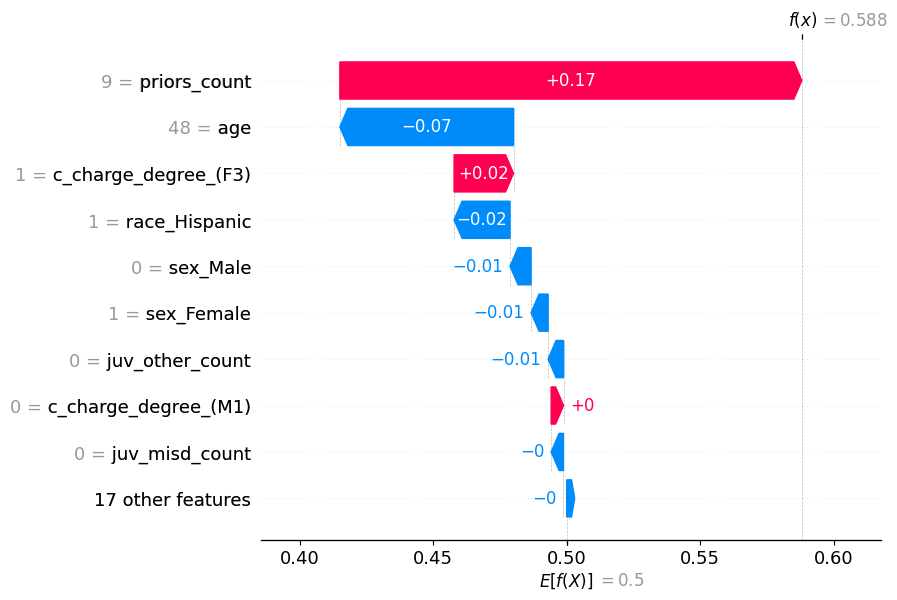

Priors pair index: 763


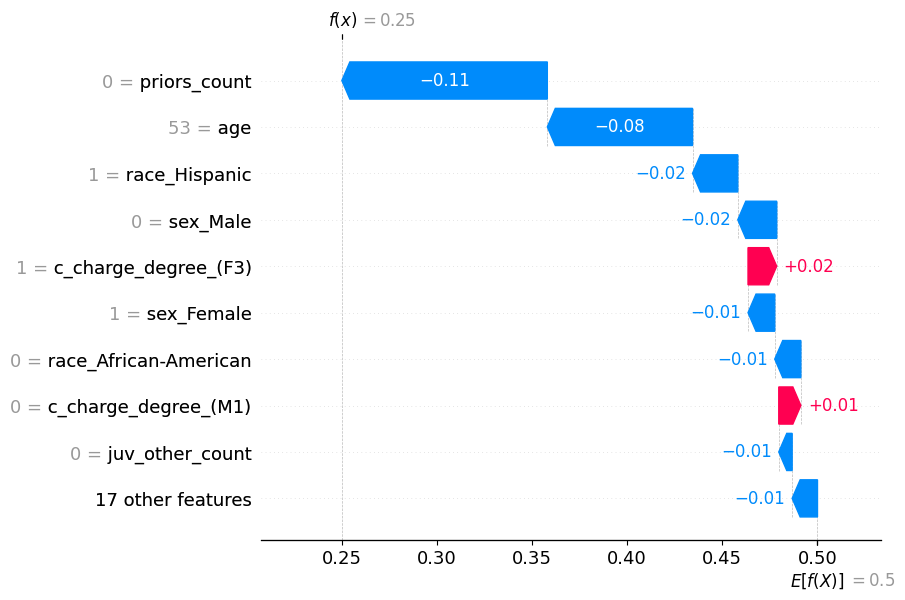

In [27]:
# priors comparison , no juv counts, race, sex, and charge_degree, older age so we eliminate the young age bias
mask_big_priors = (base2["priors_count"] >= 6) & base2["is_old"] & (base2["race"] != "African-American")
mask_zero_priors = (base2["priors_count"] == 0) & base2["is_old"] & (base2["race"] != "African-American")
priors_pair, priors_gap = pick_pair(
    base2,
    mask_big_priors,
    mask_zero_priors,
    match_cols=["race", "sex", "charge_degree", "juv_fel_count", "juv_misd_count", "juv_other_count"],
    max_age_gap=5
)
show_pair("Priors pair (9 prior counts vs 0, with less than or equal to 5 years age gap)", priors_pair, priors_gap)
# Priors pair waterfall(s)
plot_pair("Priors pair", priors_pair)


Age pair (young vs old individuals) | pred_prob gap: 0.337


,race,sex,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,charge_degree,pred_prob
39,Caucasian,Male,20,0,0,0,0,(M1),0.512734
302,Caucasian,Male,64,0,0,0,0,(M1),0.176222


Age pair index: 39


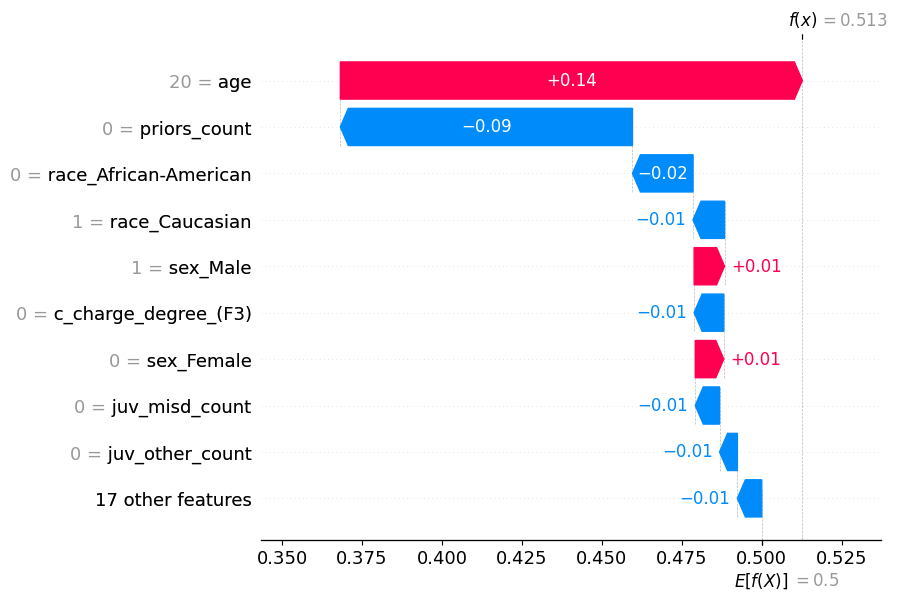

Age pair index: 302


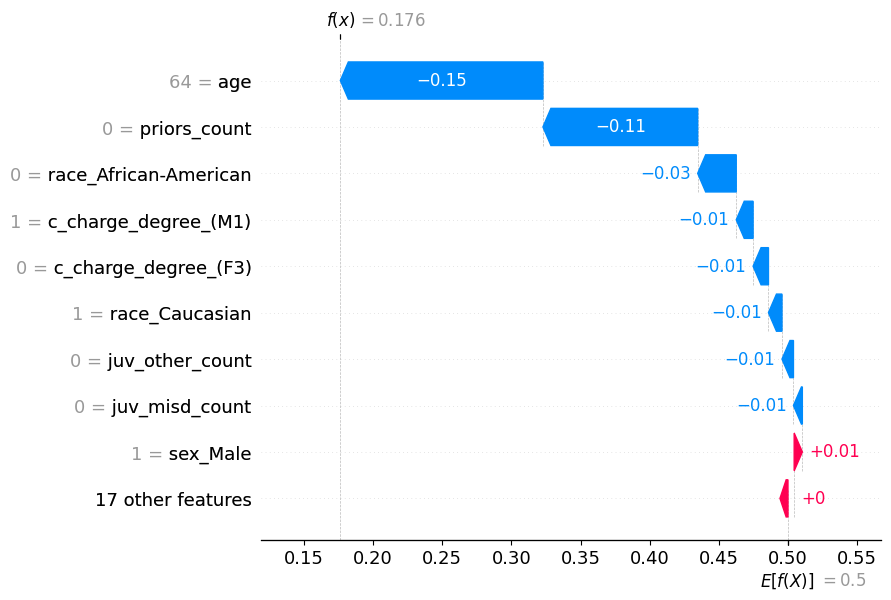

In [28]:
# comparison between a young individual and an older one with no priors or juv counts, and same race
mask_young = base2["is_young"] & (base2["race"] == "Caucasian")
mask_old = base2["is_old"] & (base2["race"] == "Caucasian")
age_pair, age_gap = pick_pair(
    base2,
    mask_young,
    mask_old,
    match_cols=["race", "sex", "charge_degree", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]
)
show_pair("Age pair (young vs old individuals)", age_pair, age_gap)
# Age pair waterfall
plot_pair("Age pair", age_pair)


 AA  vs non AA group with <=5 years age gap) | pred_prob gap: 0.214


,race,sex,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,charge_degree,pred_prob
1330,African-American,Male,52,0,0,0,0,(M1),0.370001
1890,Asian,Male,47,0,0,0,0,(M1),0.155841


Race pair index: 1330


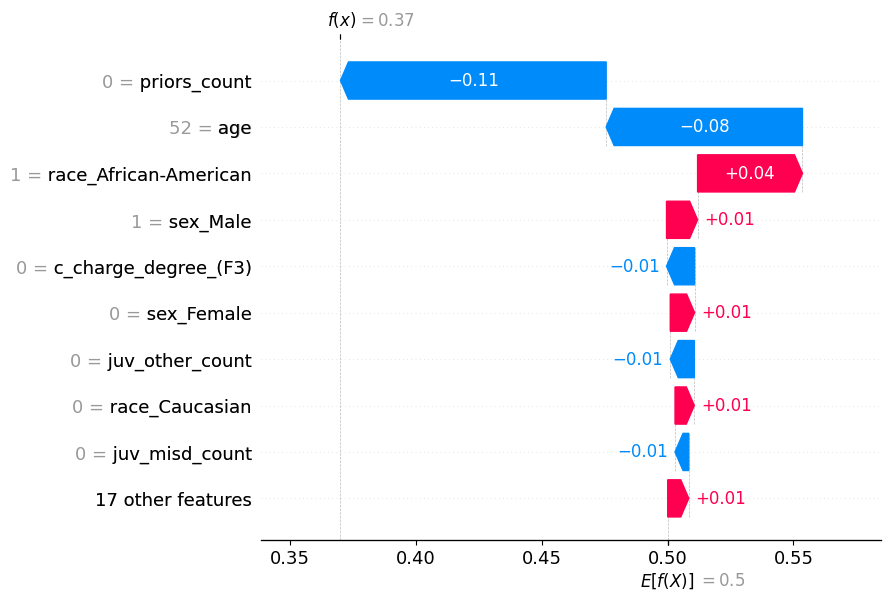

Race pair index: 1890


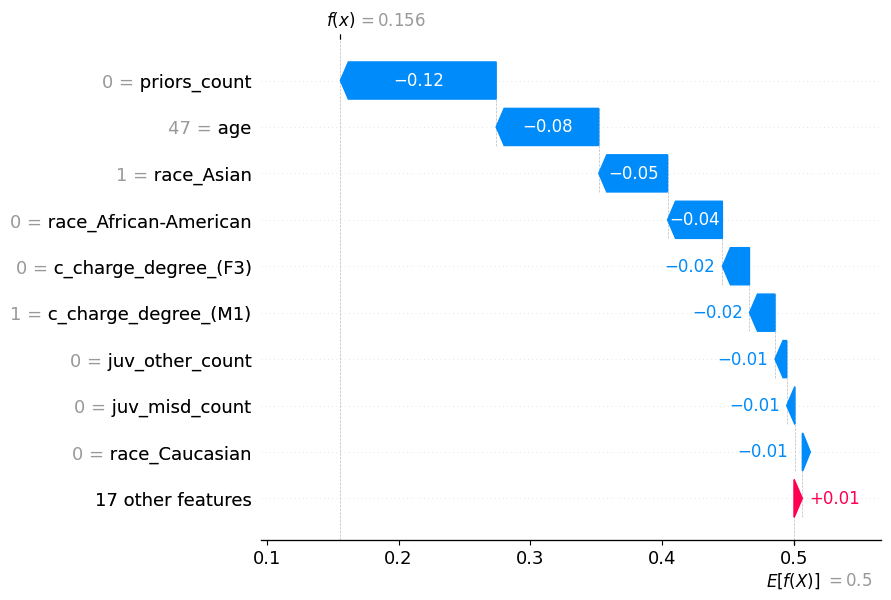

In [29]:
# comparison between African-American group and another group, with no priors or juv counts,  above 47 yrs old so we eliminate the young age bias
mask_aa = base2["is_old"] & (base2["race"] == "African-American")
mask_non_aa = base2["is_old"] & (base2["race"] != "African-American")
race_pair, race_gap = pick_pair(
    base2,
    mask_aa,
    mask_non_aa,
    match_cols=["sex", "charge_degree", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"],
    max_age_gap=5
)
#table showing the pair
show_pair(" AA  vs non AA group with <=5 years age gap)", race_pair, race_gap)
# Race pair waterfall
plot_pair("Race pair", race_pair)


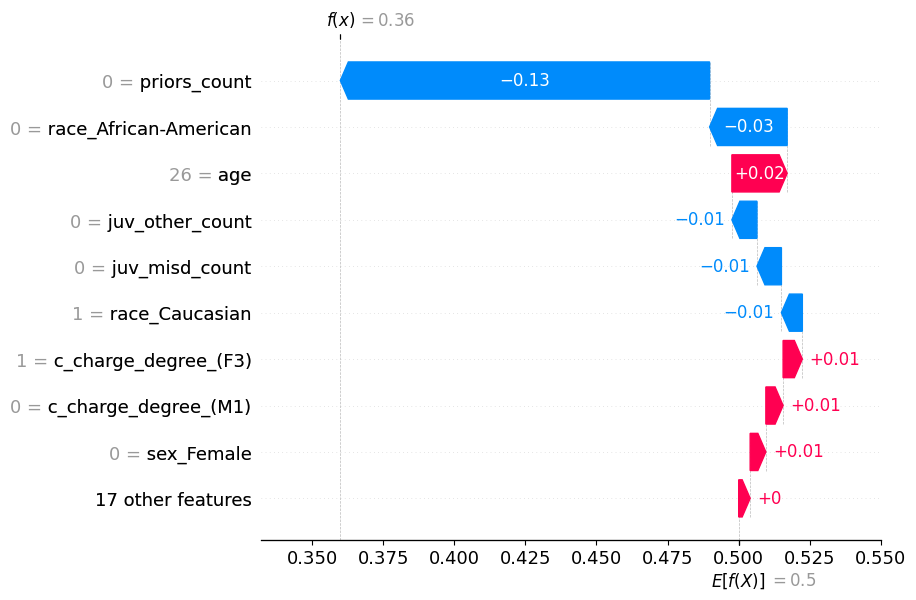

In [30]:
# Waterfall plot 
idx =8
shap.plots.waterfall(shap_class1[idx])

#34

#37

#38


# ANCHORS

In [31]:
# anchors